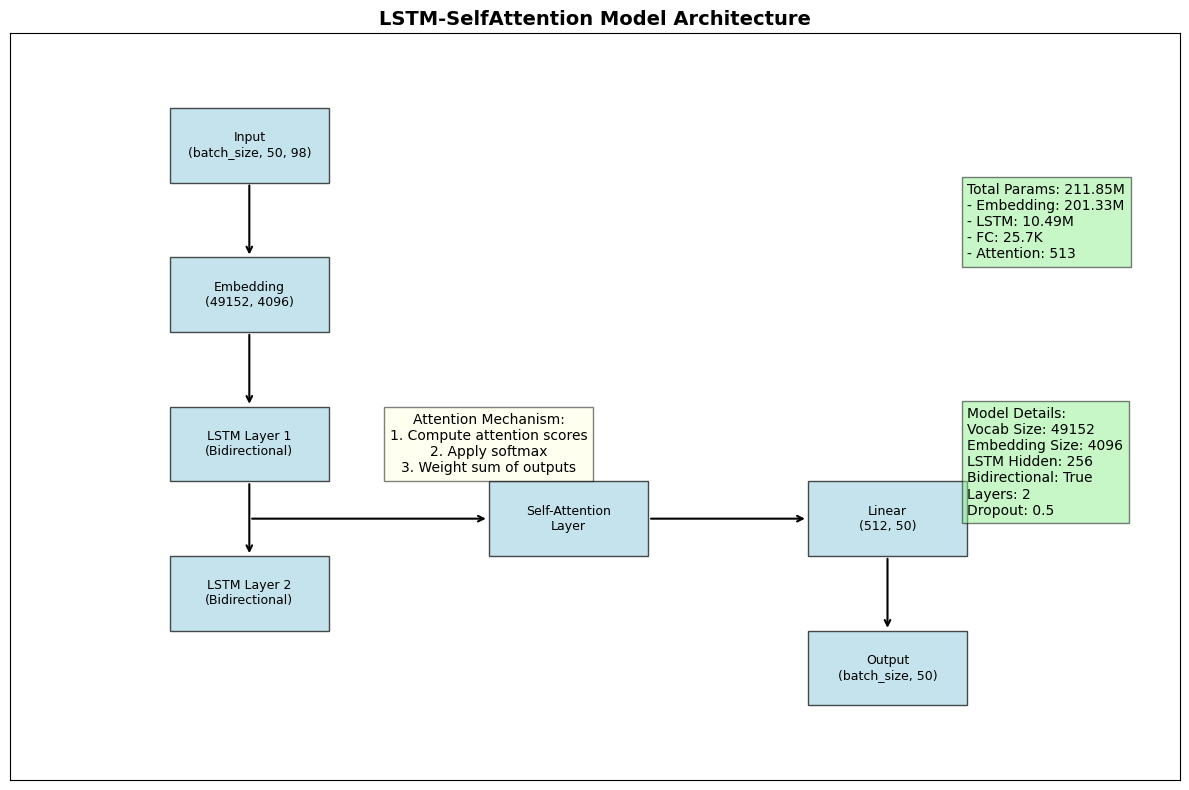

Architecture diagram saved as lstm_self_attention_diagram.png


In [2]:
# Create a manual visualization of the LSTM-SelfAttention architecture
# This will show the data flow more clearly
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
BATCH_SIZE = 10
LEARNING_RATE = 0.001
EPOCHS = 20
LSTM_NODES = 256
NUM_SENTENCES = 50
SENTENCE_LENGTH = 98
VOCAB_SIZE = 49152
EMBEDDING_SIZE = 4096
NUM_EPOCHS = 20
OUTPUT_DIM = 50
def create_architecture_diagram(save_path="lstm_self_attention_diagram.png"):
    """Create a manual diagram of the LSTM-SelfAttention architecture"""
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Component coordinates and sizes
    comps = {
        "input": {"pos": (0.1, 0.8), "width": 0.15, "height": 0.1, "label": "Input\n(batch_size, 50, 98)"},
        "embedding": {"pos": (0.1, 0.6), "width": 0.15, "height": 0.1, "label": f"Embedding\n({VOCAB_SIZE}, {EMBEDDING_SIZE})"},
        "lstm1": {"pos": (0.1, 0.4), "width": 0.15, "height": 0.1, "label": "LSTM Layer 1\n(Bidirectional)"},
        "lstm2": {"pos": (0.1, 0.2), "width": 0.15, "height": 0.1, "label": "LSTM Layer 2\n(Bidirectional)"},
        "attention": {"pos": (0.4, 0.3), "width": 0.15, "height": 0.1, "label": "Self-Attention\nLayer"},
        "fc": {"pos": (0.7, 0.3), "width": 0.15, "height": 0.1, "label": f"Linear\n({LSTM_NODES*2}, {OUTPUT_DIM})"},
        "output": {"pos": (0.7, 0.1), "width": 0.15, "height": 0.1, "label": "Output\n(batch_size, 50)"}
    }
    
    # Draw boxes for each component
    for comp_name, comp in comps.items():
        rect = patches.Rectangle(comp["pos"], comp["width"], comp["height"], 
                                linewidth=1, edgecolor='black', facecolor='lightblue', alpha=0.7)
        ax.add_patch(rect)
        ax.text(comp["pos"][0] + comp["width"]/2, comp["pos"][1] + comp["height"]/2,
               comp["label"], ha='center', va='center', fontsize=9)
    
    # Draw arrows for connections
    arrows = [
        ("input", "embedding"),
        ("embedding", "lstm1"),
        ("lstm1", "lstm2"),
        ("lstm2", "attention"),
        ("attention", "fc"),
        ("fc", "output")
    ]
    
    for start, end in arrows:
        start_pos = (comps[start]["pos"][0] + comps[start]["width"]/2, 
                    comps[start]["pos"][1])
        
        if end == "attention":
            # Special case for lstm2 -> attention (horizontal arrow)
            end_pos = (comps[end]["pos"][0], 
                      comps[end]["pos"][1] + comps[end]["height"]/2)
            ax.annotate("", xy=end_pos, xytext=(start_pos[0], end_pos[1]),
                       arrowprops=dict(arrowstyle="->", lw=1.5))
        elif start == "attention":
            # Special case for attention -> fc (horizontal arrow)
            start_pos = (comps[start]["pos"][0] + comps[start]["width"], 
                        comps[start]["pos"][1] + comps[start]["height"]/2)
            end_pos = (comps[end]["pos"][0], 
                      comps[end]["pos"][1] + comps[end]["height"]/2)
            ax.annotate("", xy=end_pos, xytext=start_pos,
                       arrowprops=dict(arrowstyle="->", lw=1.5))
        elif start == "fc":
            # Special case for fc -> output (vertical arrow)
            start_pos = (comps[start]["pos"][0] + comps[start]["width"]/2, 
                        comps[start]["pos"][1])
            end_pos = (comps[end]["pos"][0] + comps[end]["width"]/2, 
                      comps[end]["pos"][1] + comps[end]["height"])
            ax.annotate("", xy=end_pos, xytext=start_pos,
                       arrowprops=dict(arrowstyle="->", lw=1.5))
        else:
            # Default vertical arrow
            end_pos = (comps[end]["pos"][0] + comps[end]["width"]/2, 
                      comps[end]["pos"][1] + comps[end]["height"])
            ax.annotate("", xy=end_pos, xytext=start_pos,
                       arrowprops=dict(arrowstyle="->", lw=1.5))
    
    # Add attention mechanism details
    ax.text(0.4, 0.45, "Attention Mechanism:\n1. Compute attention scores\n2. Apply softmax\n3. Weight sum of outputs", 
            ha='center', va='center', bbox=dict(facecolor='lightyellow', alpha=0.5))
    
    # Add parameter count information
    params_text = (
        f"Total Params: 211.85M\n"
        f"- Embedding: 201.33M\n"
        f"- LSTM: 10.49M\n"
        f"- FC: 25.7K\n"
        f"- Attention: 513"
    )
    ax.text(0.85, 0.8, params_text, ha='left', va='top', 
            bbox=dict(facecolor='lightgreen', alpha=0.5))
    
    # Add model details
    ax.text(0.85, 0.5, 
            f"Model Details:\n"
            f"Vocab Size: {VOCAB_SIZE}\n"
            f"Embedding Size: {EMBEDDING_SIZE}\n"
            f"LSTM Hidden: {LSTM_NODES}\n"
            f"Bidirectional: True\n"
            f"Layers: 2\n"
            f"Dropout: 0.5",
            ha='left', va='top', bbox=dict(facecolor='lightgreen', alpha=0.5))
    
    # Add title
    ax.set_title("LSTM-SelfAttention Model Architecture", fontsize=14, fontweight='bold')
    
    # Remove axis ticks
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Set axis limits
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(0, 1)
    
    # Save the diagram
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Architecture diagram saved as {save_path}")

# Create the architecture diagram
create_architecture_diagram()